#Task 3 - Deep Dive Analysis & Interactive Dashboarding

###Objective
####To analyze sales data and derive meaningful business insights by tracking key performance indicators (KPIs), performing customer segmentation analysis, and developing an interactive Power BI dashboard that supports data-driven decision-making and business growth.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('/content/ApexPlanet_DataAnalytics_Dataset.xlsx')
df.head()


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [8]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


In [10]:
# Data Cleaning
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.strftime('%b')
df['YearMonth'] = df['Order_Date'].dt.to_period('M')
df['Age'].fillna(df['Age'].median(), inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)
df.isnull().sum()


/tmp/ipykernel_8625/724984781.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_8625/724984781.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


## Core KPIs

- Total Revenue = Sum(Total_Sales)
- Total Orders = Count(Order_ID)
- Average Order Value = Revenue / Orders
- Total Customers = Unique Customer_ID
- Revenue per Customer = Revenue / Customers


In [11]:
total_revenue = df['Total_Sales'].sum()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
aov = total_revenue / total_orders

print('Total Revenue:', round(total_revenue,2))
print('Total Orders:', total_orders)
print('Total Customers:', total_customers)
print('Average Order Value:', round(aov,2))


Total Revenue: 139399439.65
Total Orders: 992
Total Customers: 947
Average Order Value: 140523.63


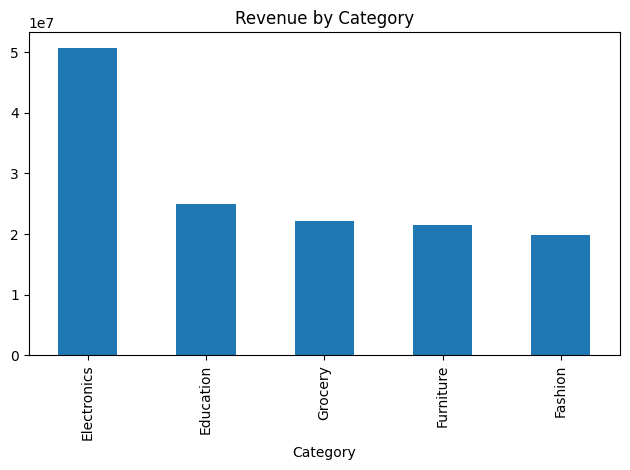

In [12]:
# Revenue by Category
category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')
plt.title('Revenue by Category')
plt.tight_layout()
plt.show()


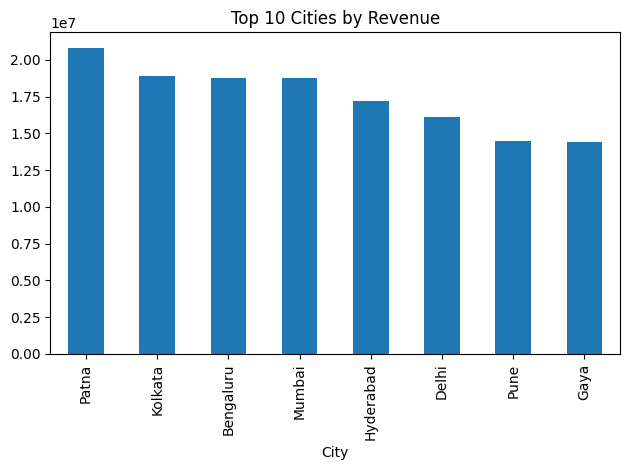

In [14]:
# Revenue by City
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False).head(10)

city_sales.plot(kind='bar')
plt.title('Top 10 Cities by Revenue')
plt.tight_layout()
plt.show()


In [16]:
# Customer Segmentation (Deep Dive)
customer_summary = df.groupby('Customer_ID').agg({
    'Total_Sales':'sum',
    'Order_ID':'count',
    'Quantity':'sum'
}).reset_index()

customer_summary.columns=['Customer_ID','Revenue','Orders','Quantity']
customer_summary.head()


,Customer_ID,Revenue,Orders,Quantity
0,CUST1004,8321.54,1,2
1,CUST1017,264230.68,1,7
2,CUST1026,164965.29,1,7
3,CUST1032,146990.90,1,7
4,CUST1038,37068.40,1,5


In [19]:
# Export dashboard datasets
category_sales.reset_index().to_csv('category_sales.csv', index=False)
city_sales.reset_index().to_csv('city_sales.csv', index=False)
customer_summary.to_csv('customer_summary.csv', index=False)
df.to_csv("cleaned_sales_dataset.csv",index=False)
print('Files exported successfully')


Files exported successfully
